# Myeloid subanalysis

In [1]:
set.seed(1)
source('./utils.R')
obj = readRDS('../_data/obj_merged_71302cells_labeled.rds')

In [2]:
table(obj@meta.data$cell_type)


              T cell           Fibroblast   Keratinocyte diff. 
               13103                11435                10614 
Keratinocyte undiff.          Vascular EC              Myeloid 
               10479                 7693                 7785 
        Lymphatic EC        Hair follicle             Pericyte 
                2816                 3546                 1544 
          Melanocyte                 Mast     Dermal adipocyte 
                1288                  633                  366 

In [3]:
objM = subset(x = obj, subset = cell_type == "Myeloid")

## Calculate variable genes in each dataset separately

In [4]:
objM_sn = subset(x = objM, subset = dataset == "snRNA-seq") %>% 
            FindVariableFeatures(selection.method = "vst", nfeatures = 1000)
objM_sc = subset(x = objM, subset = dataset == "scRNA-seq") %>%
            FindVariableFeatures(selection.method = "vst", nfeatures = 1000)

Finding variable features for layer counts

Finding variable features for layer counts



In [5]:
length(union(VariableFeatures(objM_sn), VariableFeatures(objM_sc)))

[1] 1723

## Normalization and PCA

In [6]:
.verbose = FALSE
objM = objM %>% ScaleData(features = rownames(objM), verbose = .verbose) %>% 
                RunPCA(features = c(VariableFeatures(objM_sn), VariableFeatures(objM_sc)), verbose = .verbose) %>%
                RunUMAP(dims = 1:10, verbose = .verbose)

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by ‘BiocGenerics’

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by ‘BiocGenerics’



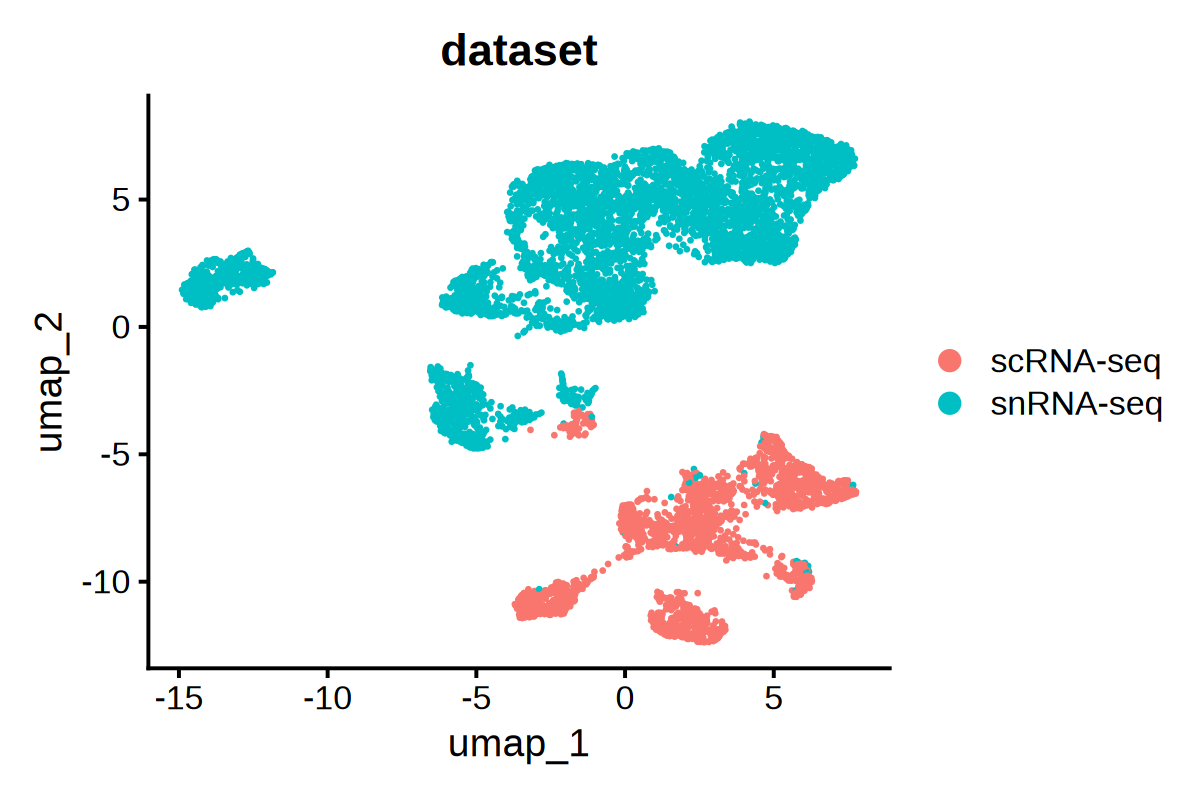

In [7]:
# pre-harmony PCA
fig.size(4, 6)
DimPlot(objM, reduction = "umap", group.by = "dataset", shuffle = TRUE)

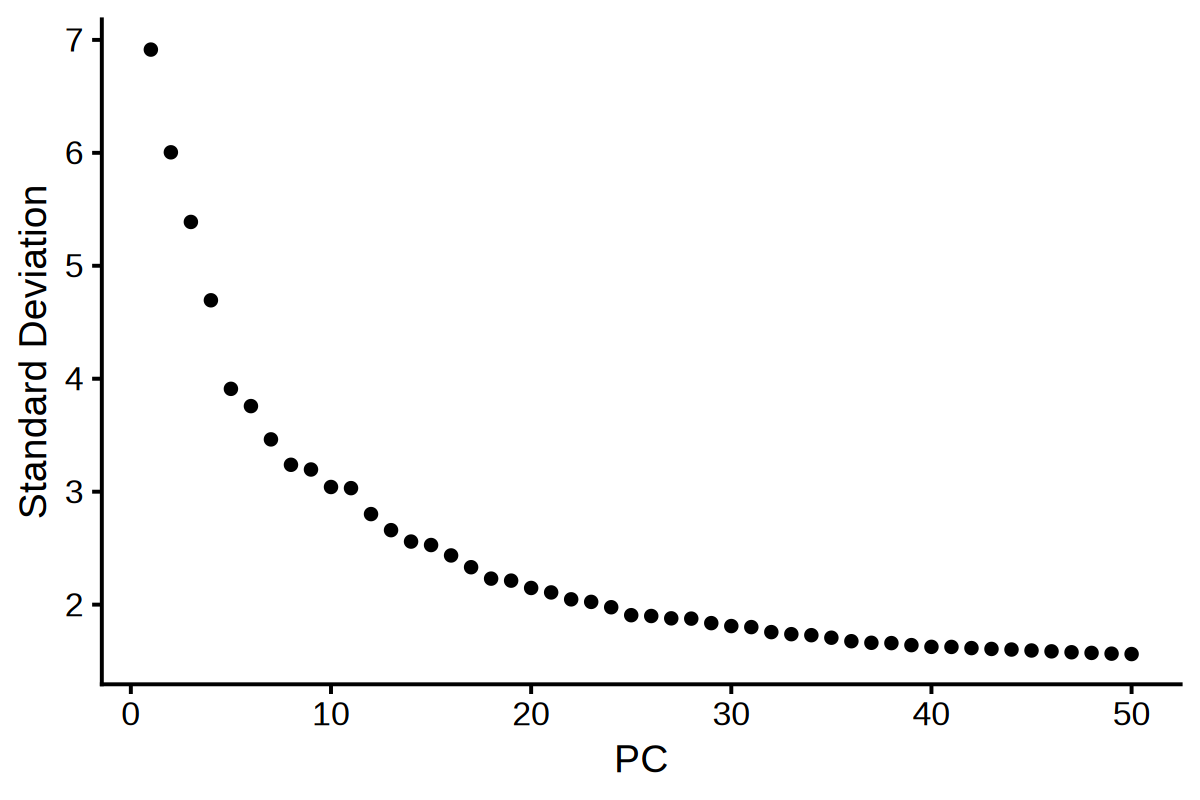

In [8]:
ElbowPlot(objM, ndims = 50, reduction = "pca")

## Harmony

Transposing data matrix

Initializing state using k-means centroids initialization

Harmony 1/10

Harmony 2/10

Harmony 3/10

Harmony 4/10

Harmony 5/10

Harmony 6/10

Harmony 7/10

Harmony converged after 7 iterations

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by ‘BiocGenerics’

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by ‘BiocGenerics’



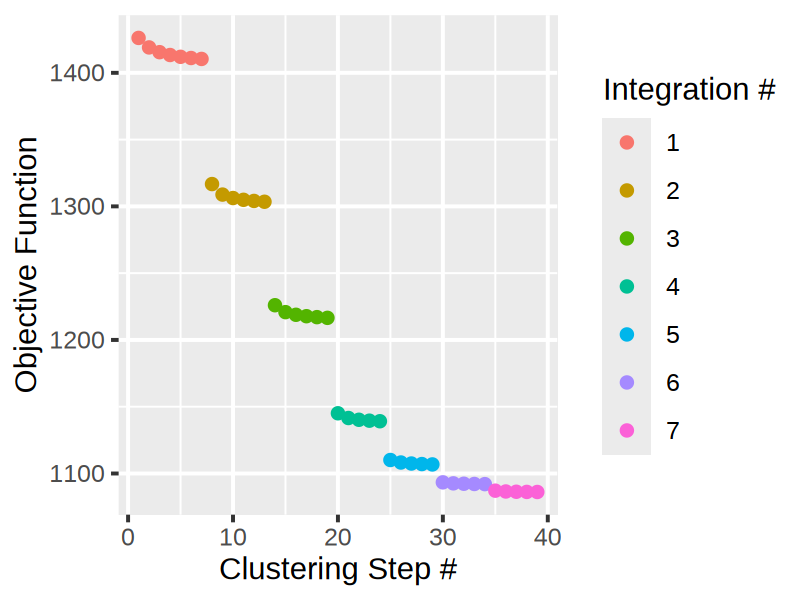

In [9]:
set.seed(1)
fig.size(3, 4)
objM = objM %>% RunHarmony(c("Subject", "dataset", "Run"), theta = c(1,1,1), plot_convergence = TRUE) %>%
    RunUMAP(reduction = "harmony", dims = 1:10, verbose = .verbose) %>% 
    FindNeighbors(reduction = "harmony", dims = 1:10, verbose = .verbose)

In [10]:
objM = objM %>% FindClusters(resolution = 0.15, verbose = .verbose) %>% 
    identity()

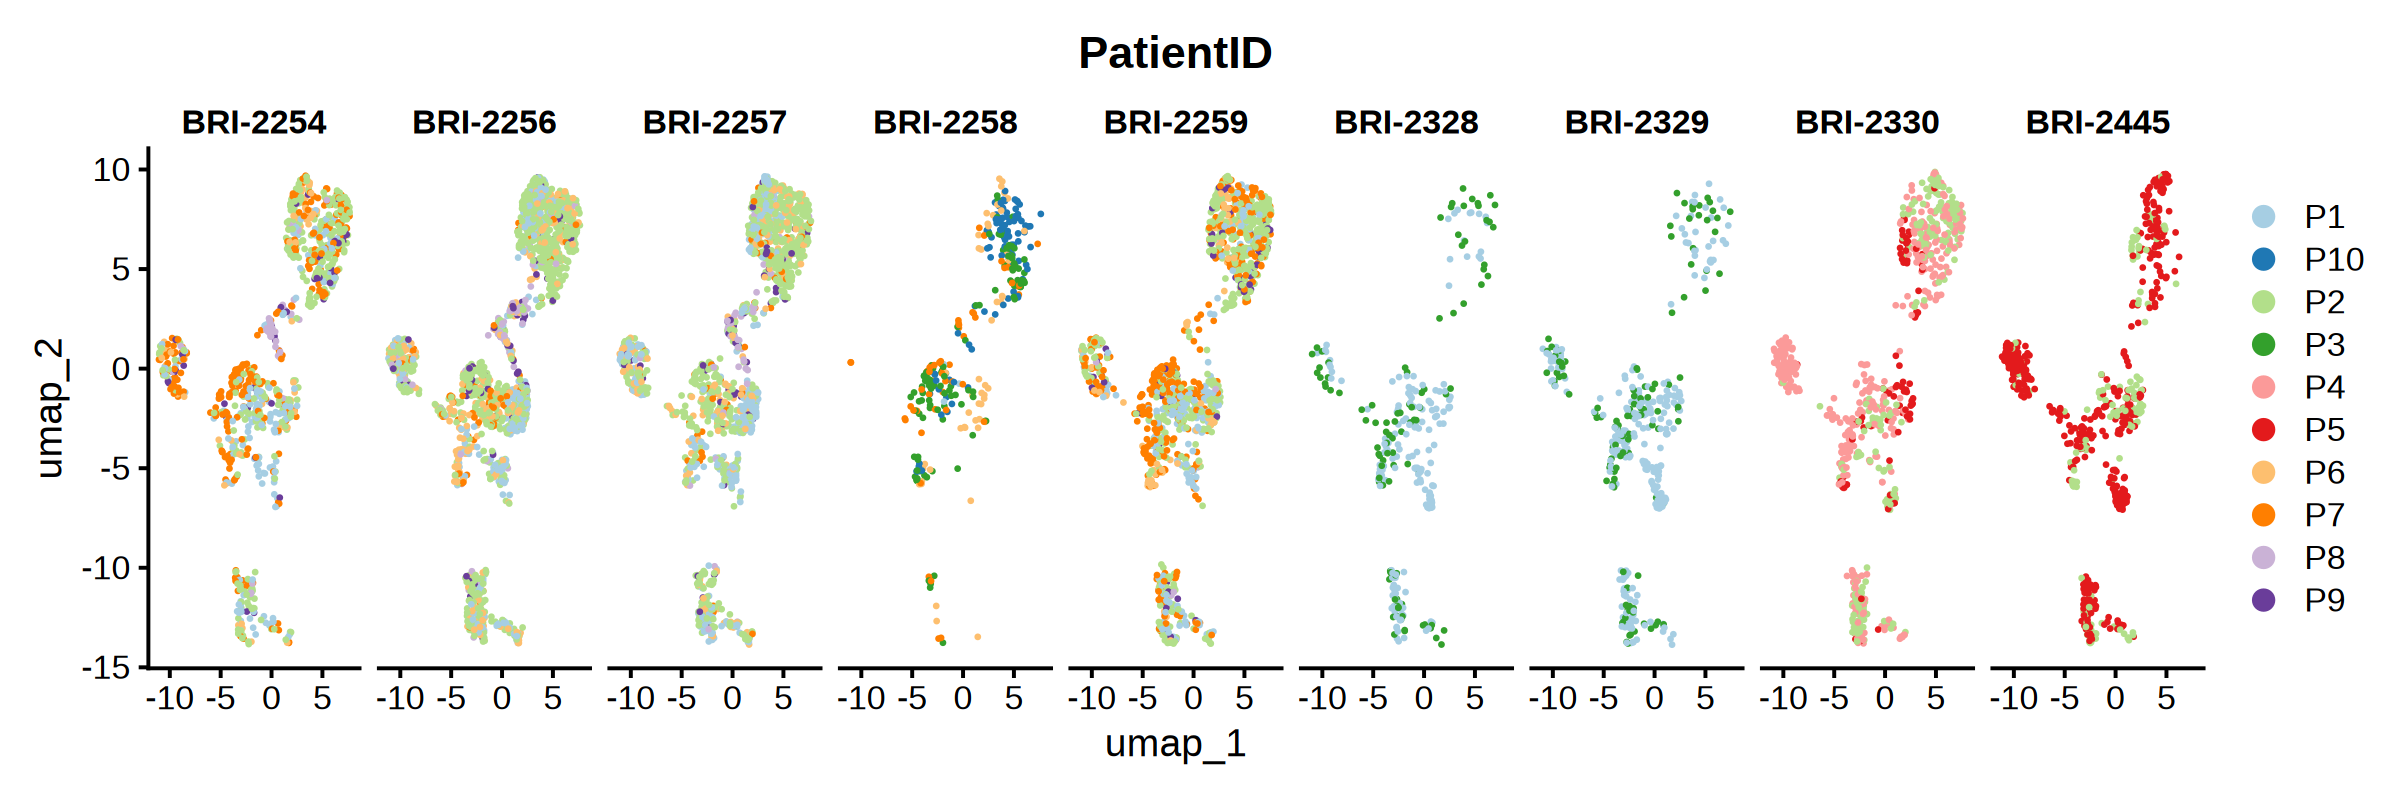

In [11]:
fig.size(4, 12)
DimPlot(objM, reduction = "umap", shuffle = TRUE, group.by = 'PatientID', split.by = 'Run') + 
    scale_color_brewer(palette = 'Paired')

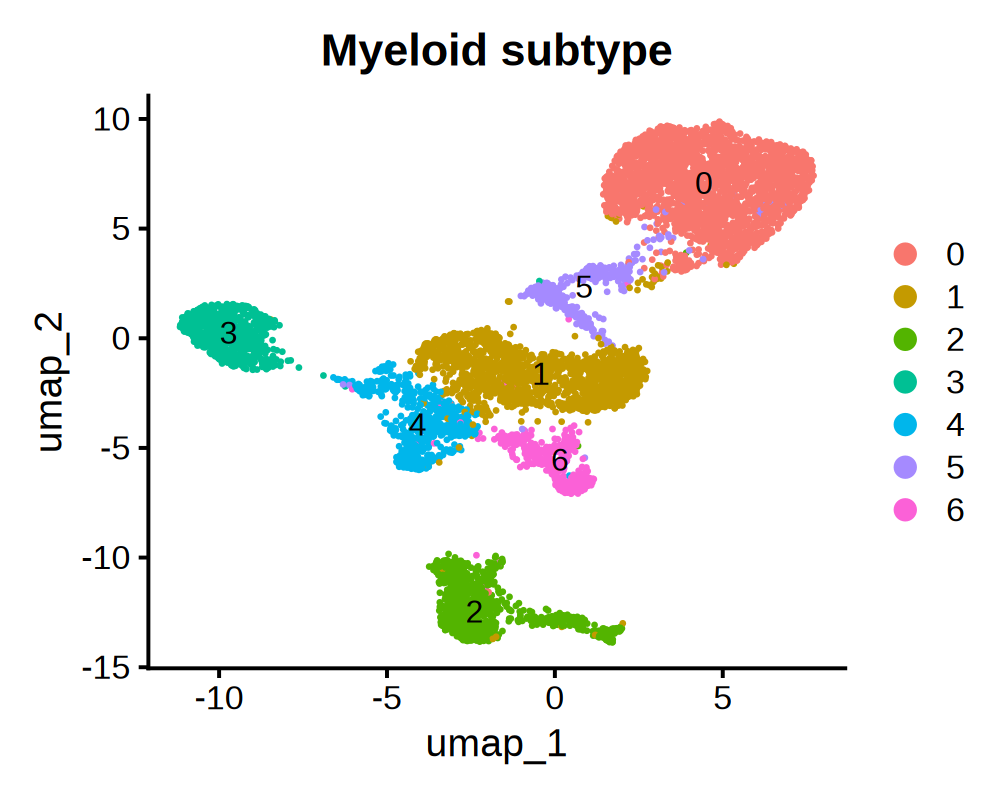

In [12]:
fig.size(4, 5)
DimPlot(objM, reduction = "umap", shuffle = TRUE, label = TRUE, group.by = 'RNA_snn_res.0.15') +
    ggtitle('Myeloid subtype')

In [13]:
objM@meta.data$M_type = paste0('Mclust', objM@meta.data$RNA_snn_res.0.15)
objM@meta.data$M_type = factor(objM@meta.data$M_type, levels = paste0('Mclust', c(0:6)))
Idents(objM) = 'M_type'

png 
  2

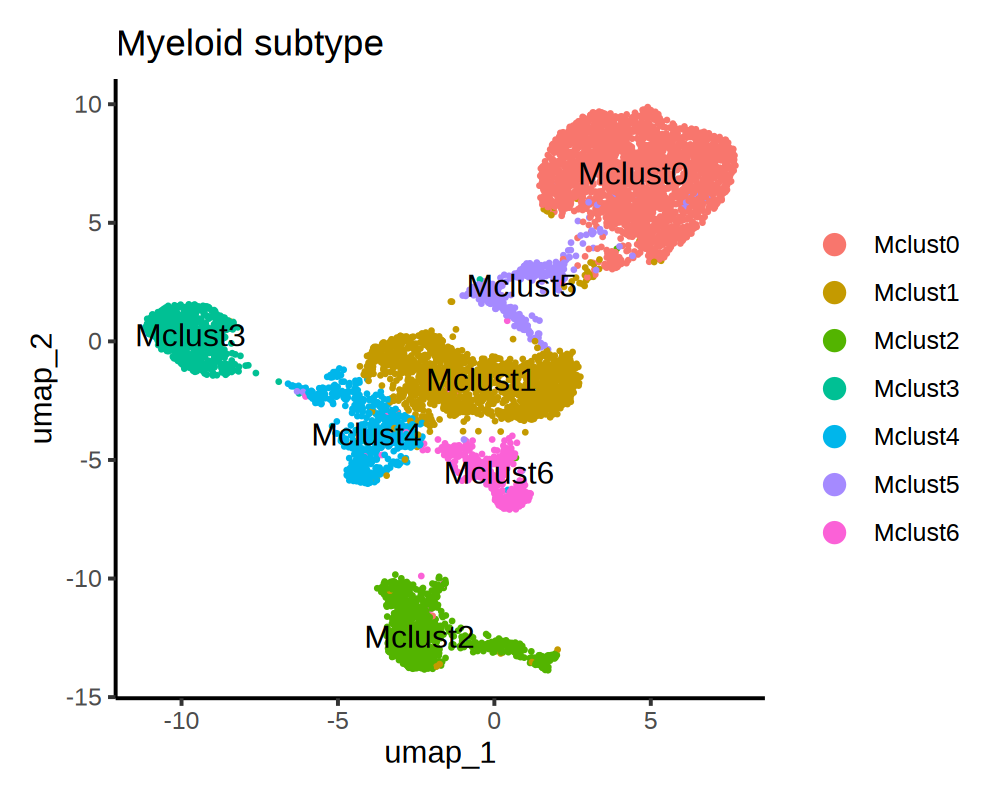

In [14]:
fig.size(4, 5)
p = DimPlot(objM, reduction = "umap", shuffle = TRUE, label = TRUE, group.by = 'M_type') +
    ggtitle('Myeloid subtype') + theme_classic()
pdf("../_figures/Myeloid_subclusters_umap.pdf", width = 5, height = 4)
print(p)
dev.off()
p

## Differential expression by cluster

In [15]:
obj_presto = wilcoxauc(objM, 'M_type')
head(obj_presto)

,feature,group,avgExpr,logFC,statistic,auc,pval,padj,pct_in,pct_out
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,SAMD11,Mclust0,0.000000000,-0.0014299878,6897140,0.4997032,2.029367e-01,3.179991e-01,0.0000000,0.05935892
2,NOC2L,Mclust0,0.059433426,-0.0298548046,6791752,0.4920678,7.283540e-04,2.406180e-03,3.0391798,4.62999604
3,KLHL17,Mclust0,0.021646749,-0.0133905045,6859012,0.4969408,3.807429e-02,8.093069e-02,1.1717320,1.78076771
4,PLEKHN1,Mclust0,0.007138247,-0.0060982516,6882792,0.4986636,1.244974e-01,2.181698e-01,0.3661662,0.63316185
5,PERM1,Mclust0,0.000000000,-0.0002006952,6899872,0.4999011,4.624458e-01,5.914560e-01,0.0000000,0.01978631
6,HES4,Mclust0,0.021014058,-0.0370010131,6765786,0.4901864,4.539165e-08,2.811094e-07,1.0618821,3.02730510


In [16]:
markers = top_markers(obj_presto, n = 6)
markers = markers[, -1]
head(markers)

Mclust0,Mclust1,Mclust2,Mclust3,Mclust4,Mclust5,Mclust6
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
F13A1,ITGAX,WDFY4,LAMP3,CLDN1,RORA,PTPRS
STAB1,RTN1,IRF8,CERS6,LCP1,SYNE2,TCF4
LGMN,CIITA,CPVL,KDM2B,GSN,TSHZ2,PLD4
FRMD4B,PID1,CADM1,FSCN1,FCGBP,PRKCH,JAML
MAMDC2,GPAT3,CLNK,NAV1,CD207,SPTBN1,ITM2C
AP2A2,JAML,CCSER1,LY75,CTNND1,KAZN,CCDC50


Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


png 
  2

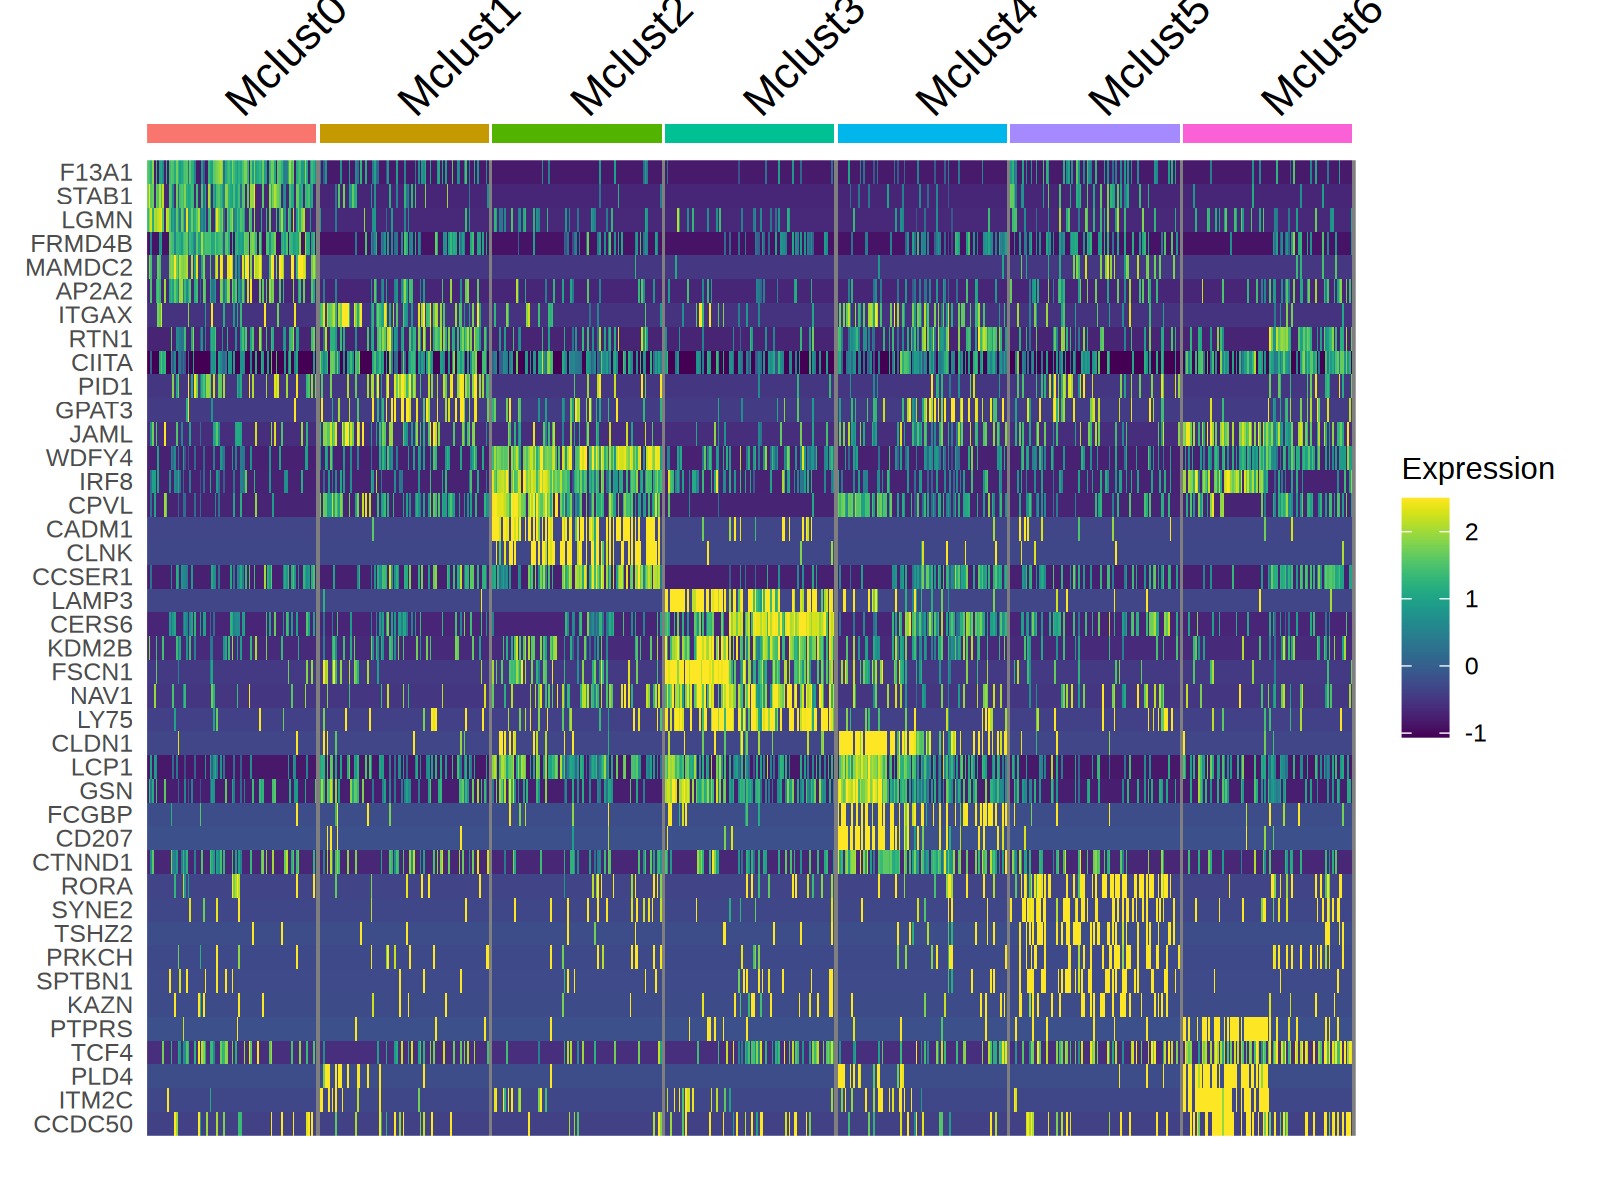

In [17]:
fig.size(6, 8)
p = DoHeatmap(subset(objM, downsample = 100), features = unlist(markers)) + 
    scale_fill_viridis() + guides(colour="none") 
pdf('../_figures/Myeloid_cluster_DE_heatmap.pdf', width = 8, height = 6)
print(p)
dev.off()
p

## Marker genes

png 
  2

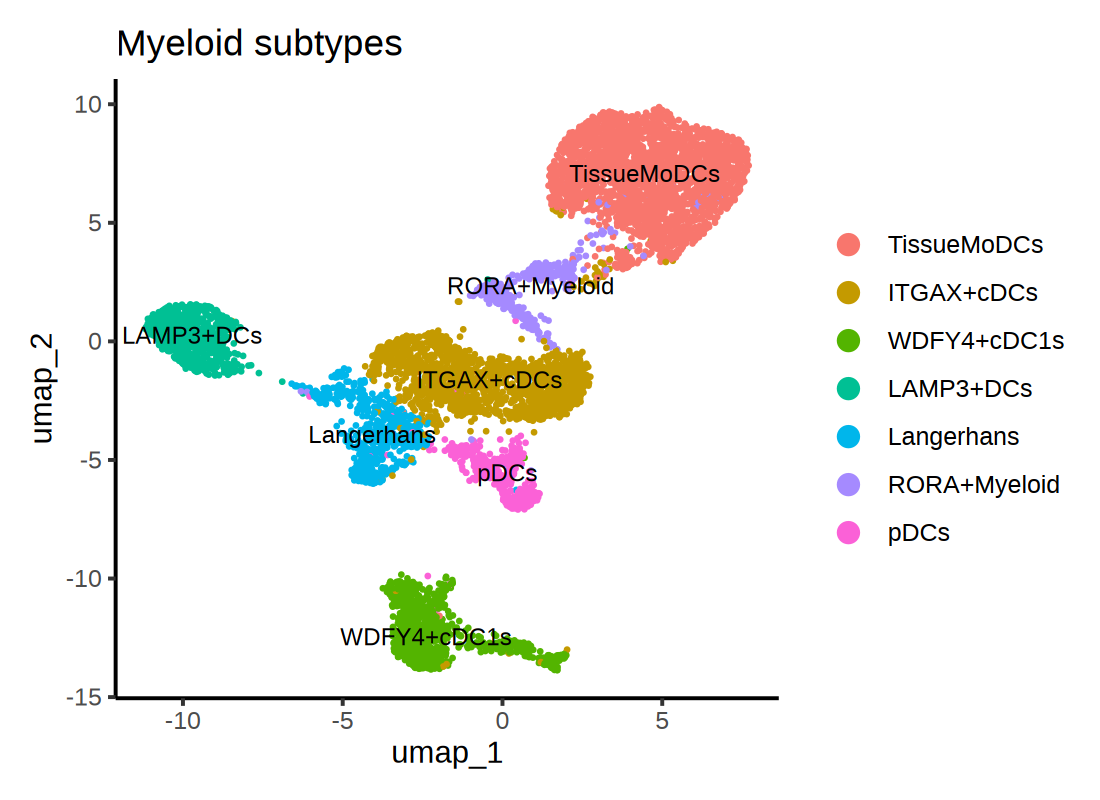

In [18]:
new.cluster.ids <- c("TissueMoDCs", "ITGAX+cDCs", "WDFY4+cDC1s",
                     "LAMP3+DCs", "Langerhans", "RORA+Myeloid", "pDCs")
names(new.cluster.ids) <- levels(objM)
objM <- RenameIdents(objM, new.cluster.ids)

fig.size(4, 5.5)
p = DimPlot(objM, reduction = "umap", shuffle = TRUE, label = TRUE, label.size = 3) +
    ggtitle('Myeloid subtypes') + theme_classic()
pdf("../_figures/Myeloid_subclusters_umap_labeled.pdf", width = 5.5, height = 4)
print(p)
dev.off()
p

In [19]:
objM$myeloid_subtype = Idents(objM)
saveRDS(objM, '../_data/obj_merged_myeloid_labeled.rds')

png 
  2

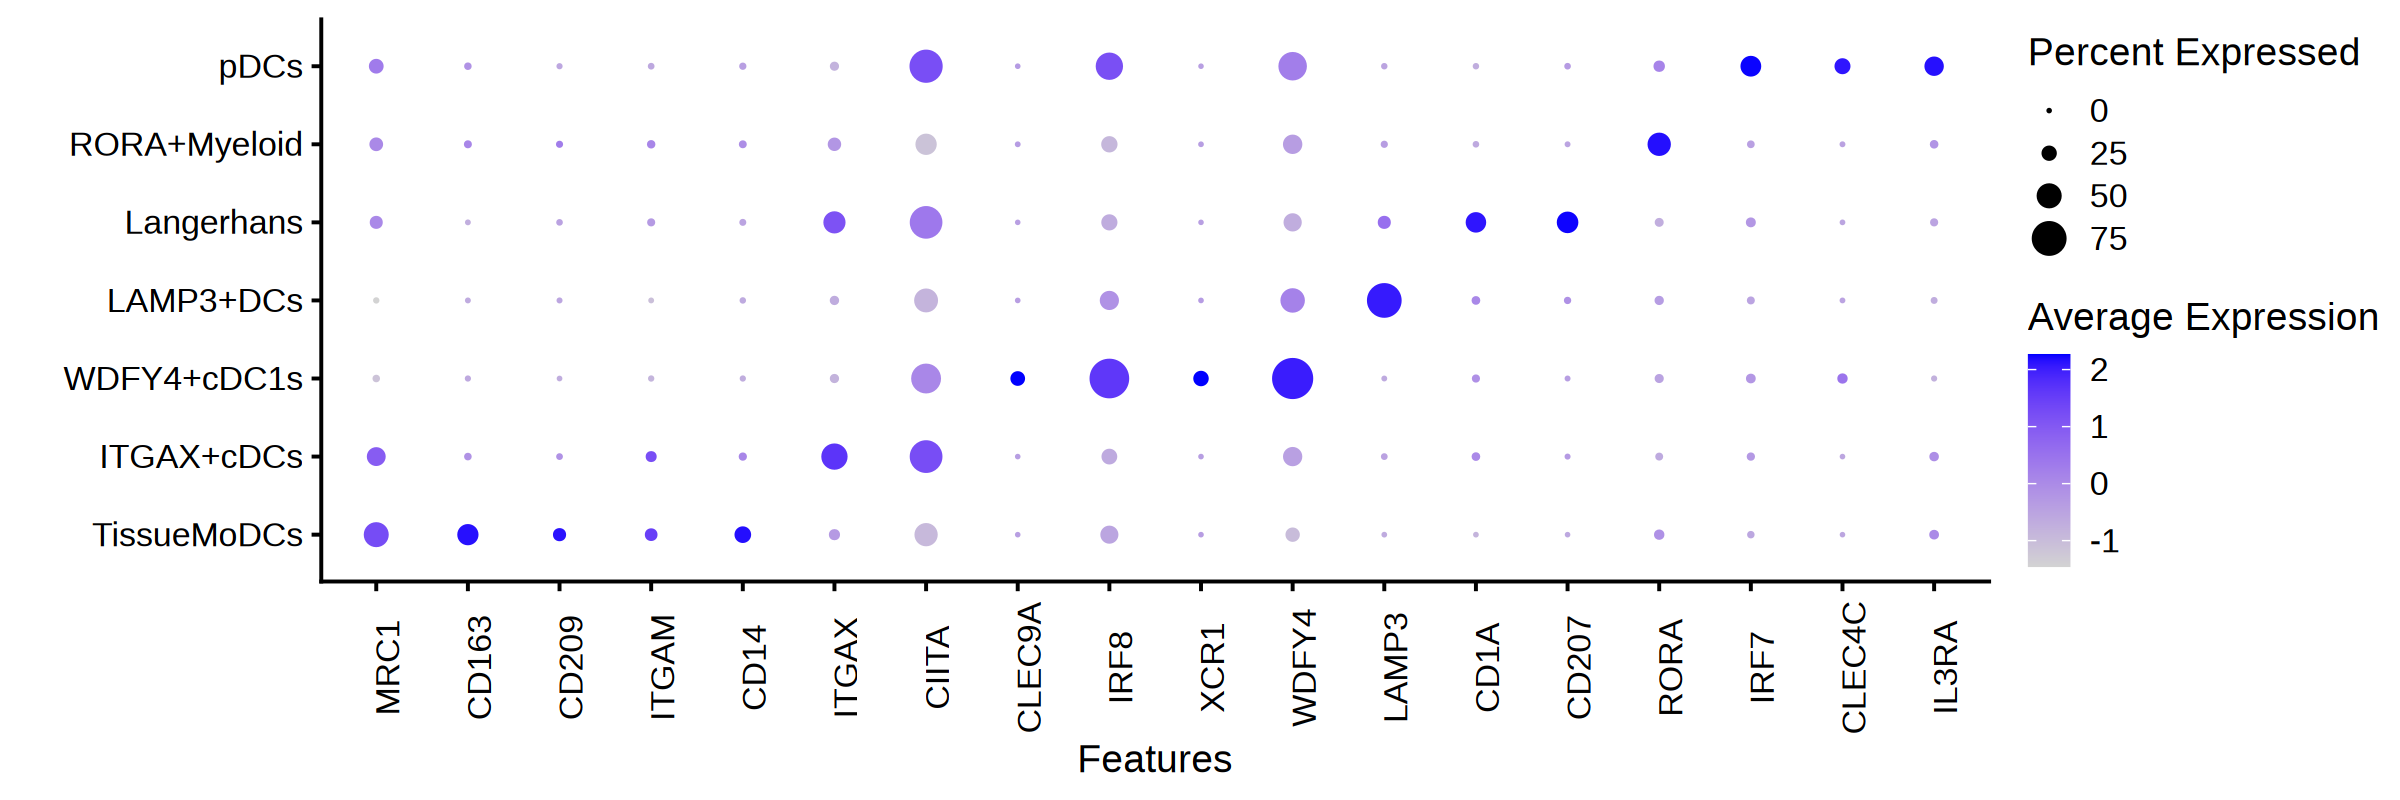

In [21]:
fig.size(4, 12)
d = DotPlot(objM, features = c("MRC1", "CD163", "CD209", "ITGAM", "CD14", # Tissue MoDCs
                           "ITGAX", "CIITA", # cDC
                           "CLEC9A", "IRF8", "XCR1", "WDFY4", # cDC1
                           "LAMP3", # LAMP3+ DC
                           "CD1A", "CD207", # Langerhans
                           "RORA",
                           "IRF7", "CLEC4C", "IL3RA")) + # pDC
            ylab('') + theme(axis.text.x = element_text(angle = 90))
pdf('../_figures/myeloid_dotplot.pdf', width = 12, height = 4)
print(d)
dev.off()
d

png 
  2

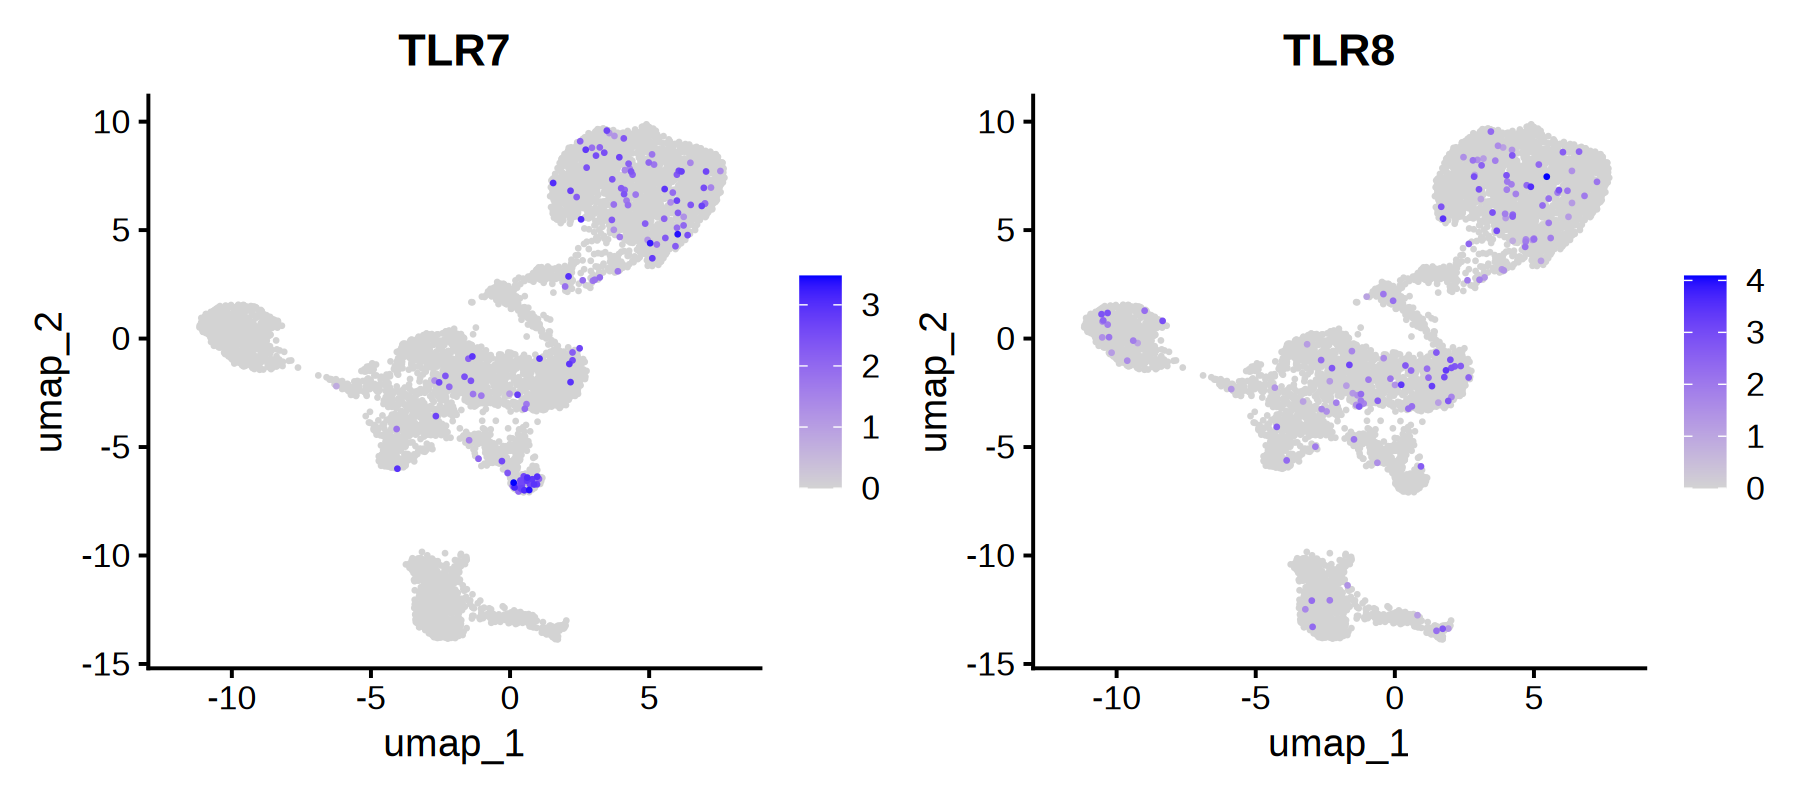

In [22]:
fig.size(4, 9)

pdf('../_figures/Myeloid_TLR7_8_UMAP.pdf', width = 9, height = 4)
p = FeaturePlot(objM, features = c('TLR7', 'TLR8'), order = TRUE)
print(p)
dev.off()
p

png 
  2

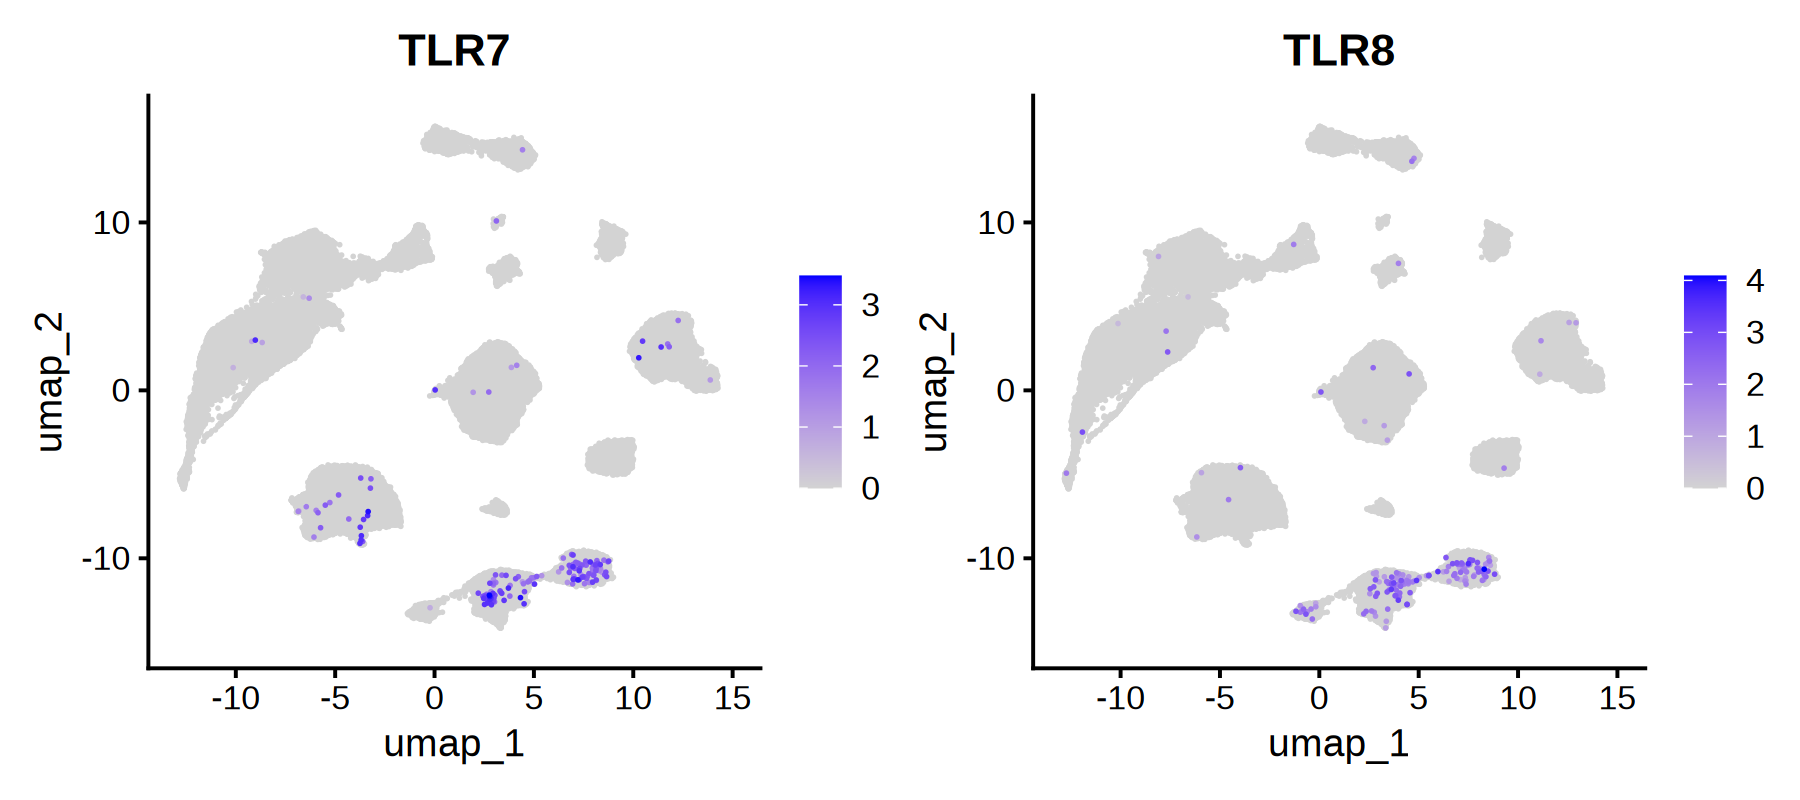

In [23]:
fig.size(4, 9)

pdf('../_figures/TLR7_8_UMAP.pdf', width = 9, height = 4)
p = FeaturePlot(obj, features = c('TLR7', 'TLR8'), order = TRUE)
print(p)
dev.off()
p

In [29]:
p1 = DotPlot(obj, features = c("TLR7", "TLR8")) + #, order = TRUE)
            theme(axis.text.x = element_text(angle = 90)) + ylab('') + xlab('')
p2 = DotPlot(objM, features = c("TLR7", "TLR8")) + #, order = TRUE)
            theme(axis.text.x = element_text(angle = 90)) + ylab('')
fig.size(4.5, 5)
pdf('../_figures/TLR_dotplots_all_cells.pdf', height = 4.5, width = 5)
print(p1)
dev.off()
fig.size(4.5, 5)
pdf('../_figures/TLR_dotplots_myeloid.pdf', height = 4.5, width = 5)
print(p2)
dev.off()

png 
  2

png 
  2

## Are cluster frequencies different by condition?

`summarise()` has grouped output by 'Subject_TimePt', 'TimePt'. You can
override using the `.groups` argument.


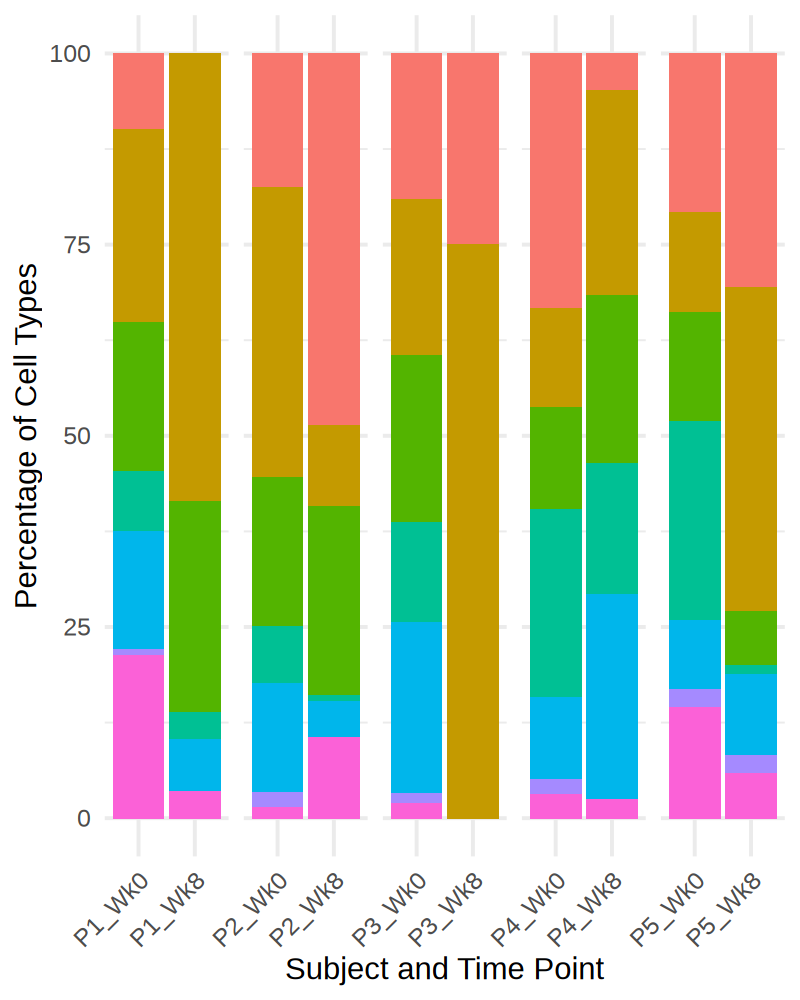

In [30]:
objM@meta.data$cell_typeM = Idents(objM)
mydata = cbind(objM@meta.data, objM@reductions$umap@cell.embeddings)

# Create a combined variable for Subject and TimePt
data <- mydata %>% filter(dataset == 'scRNA-seq') %>%
  mutate(Subject_TimePt = paste(PatientID, TimePt, sep = "_"))

# Summarize the data to get the percentage of each cell type per Subject+TimePt
data_summary1 <- data %>%
  group_by(Subject_TimePt, TimePt, cell_typeM) %>%
  summarise(cell_count = n()) %>%
  mutate(percent = (cell_count / sum(cell_count)) * 100) %>%
  mutate(Pair_Group = gsub("Wk8", "Wk", gsub("Wk0", "Wk", Subject_TimePt))) %>%
  mutate(Pair_Group = paste0('sc', Pair_Group)) %>%
  ungroup()

fig.size(5, 4)
# Create the stacked bar plot
p1 = ggplot(data_summary1, aes(x = Subject_TimePt, y = percent, fill = cell_typeM)) +
  geom_bar(stat = "identity") +
  labs(x = "Subject and Time Point", y = "Percentage of Cell Types") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  labs(fill = '') +
  facet_grid(. ~ Pair_Group, scales = "free_x", space = "free_x") +
  theme(strip.text.x = element_blank(), legend.position = 'none')

p1

`summarise()` has grouped output by 'Subject_TimePt', 'TimePt', 'Type'. You can
override using the `.groups` argument.


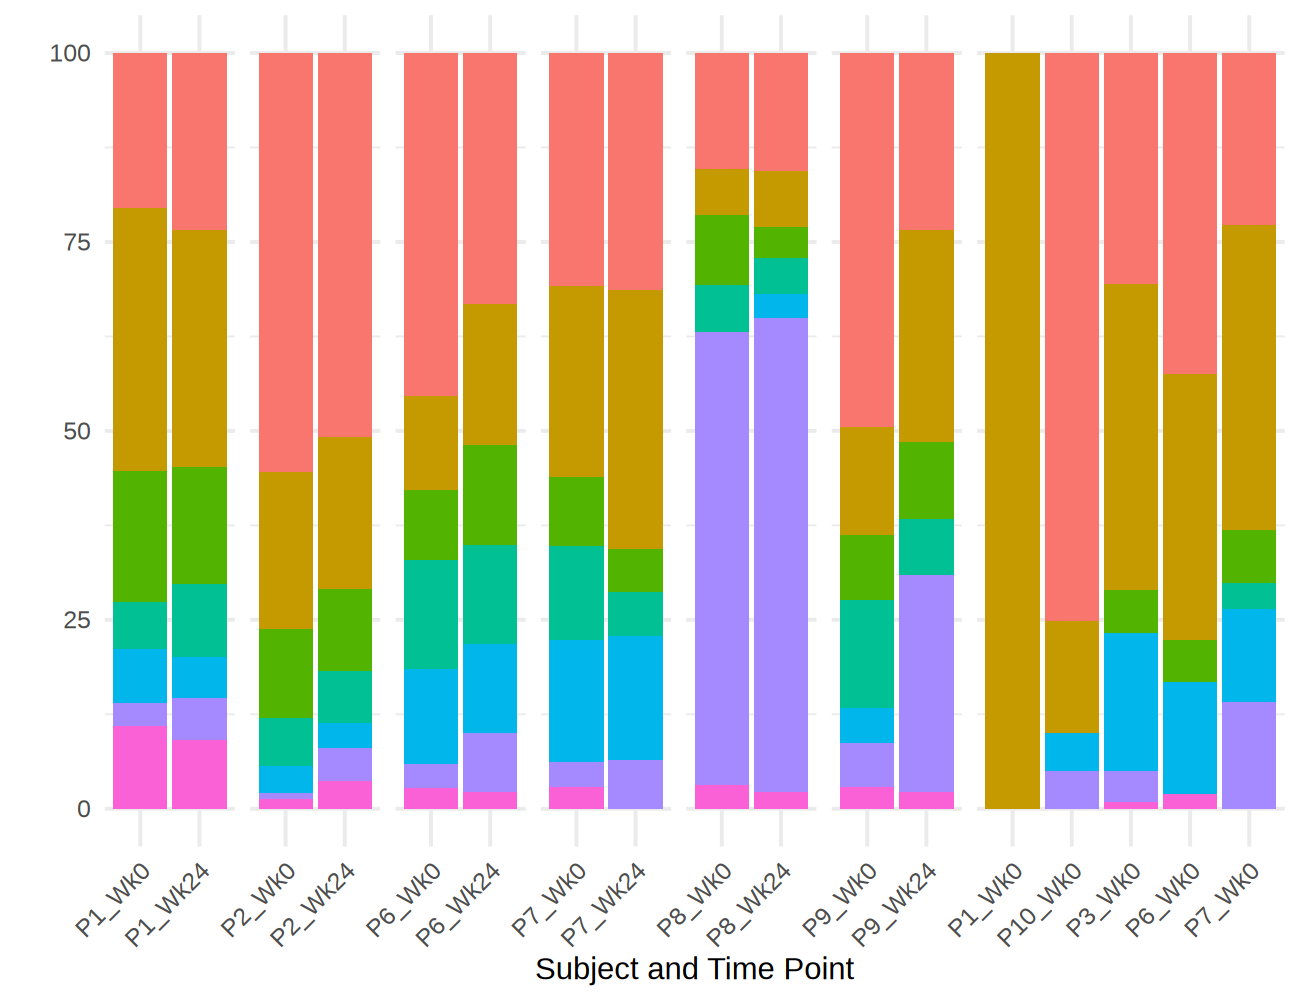

In [31]:
# Create a combined variable for Subject and TimePt
data <- mydata %>% filter(dataset == 'snRNA-seq') %>%
  mutate(Subject_TimePt = paste(PatientID, TimePt, sep = "_"))

# Summarize the data to get the percentage of each cell type per Subject+TimePt
data_summary2 <- data %>% group_by(Subject_TimePt, TimePt, Type, cell_typeM) %>%
  summarise(cell_count = n()) %>%
  mutate(percent = (cell_count / sum(cell_count)) * 100) %>%
  mutate(Pair_Group = ifelse(Type == 'LesUntx', gsub("Wk24", "Wk", gsub("Wk0", "Wk", Subject_TimePt)), 'z')) %>%
  mutate(Pair_Group = paste0('sn', Pair_Group)) %>%
  ungroup()

fig.size(5, 6.5)
# Create the stacked bar plot
p2 = ggplot(data_summary2, aes(x = Subject_TimePt, y = percent, fill = cell_typeM)) +
  geom_bar(stat = "identity") +
  labs(x = "Subject and Time Point", y = "") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  labs(fill = '') +
  facet_grid(. ~ Pair_Group, scales = "free_x", space = "free_x") +
  theme(strip.text.x = element_blank(), legend.position = 'none')

p2

In [32]:
df = data_summary2 %>% filter(TimePt == 'Wk0')
res = NULL
for (ct in unique(df$cell_typeM)) {
    df_ct = df %>% filter(cell_typeM == ct)
    NL = df_ct %>% filter(Pair_Group == 'snz')
    LesUntx = df_ct %>% filter(Pair_Group != 'snz')
    w = wilcox.test(NL$percent, LesUntx$percent)
    myres = data.frame(cell_type = ct, NL_avg_pct = mean(NL$percent), LesUntx_avg_pct = mean(LesUntx$percent),
                       p_val = w$p.value)
    res = rbind(res, myres)
}

In [33]:
res$p_val_adj = p.adjust(res$p_val, method = 'fdr')
res

cell_type,NL_avg_pct,LesUntx_avg_pct,p_val,p_val_adj
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
TissueMoDCs,42.806412,36.205175,0.91428571,0.9142857
ITGAX+cDCs,46.176683,18.982330,0.03030303,0.1060606
Langerhans,12.556957,8.860695,0.41269841,0.4814815
RORA+Myeloid,7.705938,12.663912,0.38095238,0.4814815
WDFY4+cDC1s,6.119408,10.858484,0.02380952,0.1060606
LAMP3+DCs,3.508772,9.983765,0.28571429,0.4814815
pDCs,1.339149,3.922422,0.14285714,0.3333333


In [34]:
sessionInfo()

R version 4.3.1 (2023-06-16)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: CentOS Linux 7 (Core)

Matrix products: default
BLAS/LAPACK: /PHShome/jbk37/anaconda3/envs/resiq1/lib/libopenblasp-r0.3.25.so;  LAPACK version 3.11.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: America/New_York
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] rlang_1.1.3                 org.Hs.eg.db_3.18.0        
 [3] AnnotationDbi_1.64.1        msigdbr_7.5.1              
 [5] clusterProfiler_4.10.0      patchwork_1.3.0.9000       
 [7] RColorBrewer_1.